In [1]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

def load_custom_data(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Filter out only the lines that start with "D:" and remove the prefix
    d_lines = [line.strip()[2:].strip() for line in lines if line.startswith("D:")]

    # Check that we have at least two lines (one for header, one for column names)
    if len(d_lines) < 2:
        raise ValueError("Not enough data lines with 'D:' prefix found.")

    # The first "D:" line might be descriptive; the second one has the actual column names.
    header_line = d_lines[1]
    data_lines = d_lines[2:]

    # Create a CSV-formatted string (header + data lines)
    csv_data = "\n".join([header_line] + data_lines)

    # Use StringIO to load the string as if it were a file
    df = pd.read_csv(StringIO(csv_data), sep="\t")
    return df

# Load the data
file_path = 'meritve_vzmet_zunanji_ks.txt'
df = load_custom_data(file_path)

# Inspect the DataFrame
print(df.head())

# Optionally, if you want to rename columns for clarity, you could do so:
df.rename(columns={
    '(0x20000034,6)': 'CyberGearMotorList[0].angle',
    '(0x2000012c,6)': 'LegGeometryList[0].l',
    '(0x2000013c,6)': 'LegGeometryList[0].x_c',
    '(0x20000140,6)': 'LegGeometryList[0].y_c',
    '(0x200005a8,6)': 'springConstant',
    '(0x200005b4,6)': 'cur1',
    '(0x200005b8,6)': 'cur2',
    '(0x200005ac,6)': 'dampingConstant',
    '(0x20000130,6)': 'LegGeometryList[0].l_dot',
    '(0x200005b0,6)': 'F',
    '(0x20000148,6)': 'LegGeometryList[0].l_eq',
    '(0x20000070,6)': 'CyberGearMotorList[1].angle',
    '(0x2000004c,6)': 'CyberGearMotorList[0].velocity',
    '(0x20000054,6)': 'CyberGearMotorList[0].torque',
    '(0x20000088,6)': 'CyberGearMotorList[1].velocity',
    '(0x20000090,6)': 'CyberGearMotorList[1].torque'
}, inplace=True)




   time(ms)  (0x20000034,6)  (0x2000012c,6)  (0x2000013c,6)  (0x20000140,6)  \
0      0.85        1.569843        0.293270        0.050057        0.293270   
1      5.25        1.569843        0.293270        0.050057        0.293270   
2      9.47        1.569843        0.293270        0.050076        0.293118   
3     13.84        1.569461        0.293118        0.050076        0.293118   
4     18.10        1.569461        0.293118        0.050076        0.293118   

   (0x200005a8,6)  (0x200005b4,6)  (0x200005b8,6)  (0x200005ac,6)  \
0             0.0            -0.0             0.0             0.0   
1             0.0            -0.0             0.0             0.0   
2             0.0            -0.0             0.0             0.0   
3             0.0            -0.0             0.0             0.0   
4             0.0            -0.0             0.0             0.0   

   (0x20000130,6)  (0x200005b0,6)  (0x20000148,6)  (0x20000070,6)  \
0             0.0            -0.0        

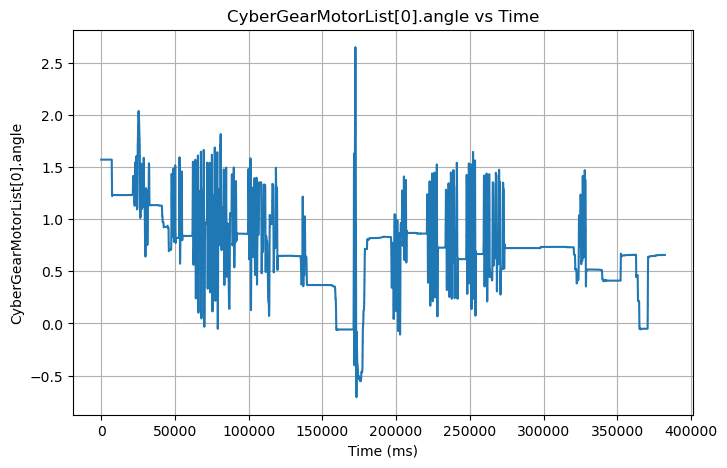

In [2]:
# For example, plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
plt.figure(figsize=(8, 5))
plt.plot(df['time(ms)'], df['CyberGearMotorList[0].angle'])
plt.xlabel('Time (ms)')
plt.ylabel('CyberGearMotorList[0].angle')
plt.title('CyberGearMotorList[0].angle vs Time')
plt.grid(True)
plt.show()

# PODATKI ZA K = 15 D = 0

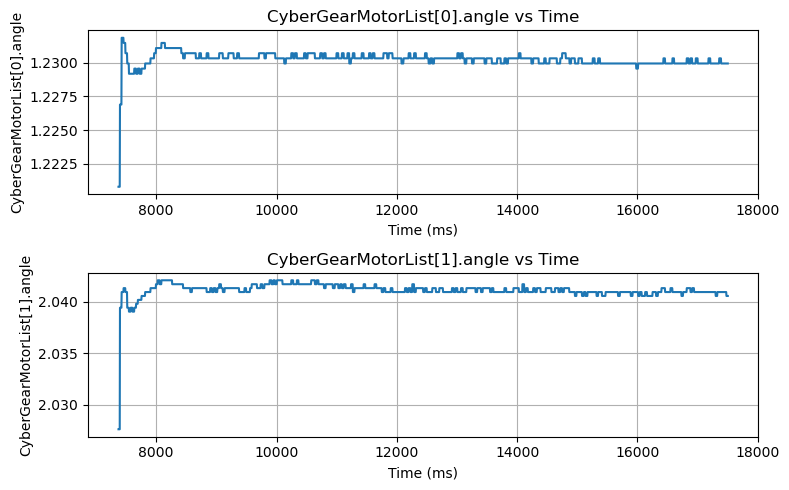

In [ ]:
#start_spring_15_damp_0 = 1531
start_spring_15_damp_0 = 1595
end_spring_15_damp_0 = 3864

# Plot the data inside this range
filtered_df = df.iloc[start_spring_15_damp_0:end_spring_15_damp_0]
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))


# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df['time(ms)'], filtered_df['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df['time(ms)'], filtered_df['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()





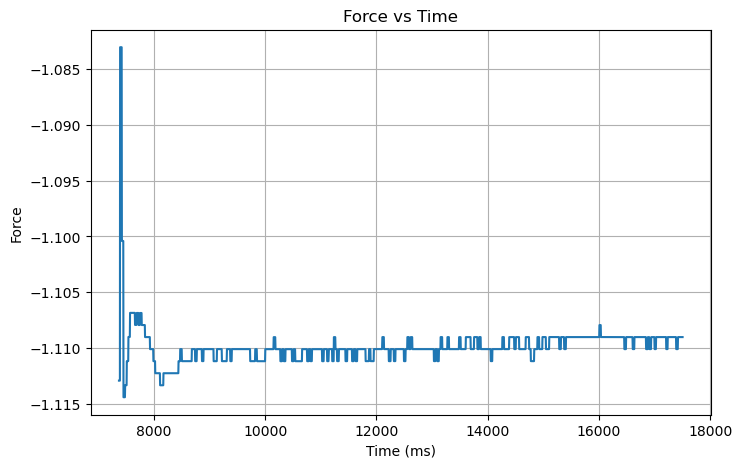

In [12]:
# Plot the force vs time inside the same range
plt.figure(figsize=(8, 5))
plt.plot(filtered_df['time(ms)'], filtered_df['F'])
plt.xlabel('Time (ms)')
plt.ylabel('Force')
plt.title('Force vs Time')
plt.grid(True)
plt.show()



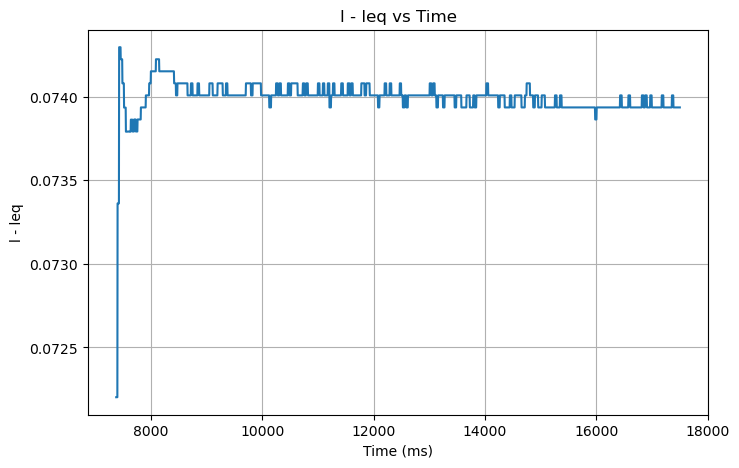

In [13]:
# Plot l - leq vs time inside the same range
plt.figure(figsize=(8, 5))
plt.plot(filtered_df['time(ms)'], filtered_df['LegGeometryList[0].l'] - filtered_df['LegGeometryList[0].l_eq'])
plt.xlabel('Time (ms)')
plt.ylabel('l - leq')
plt.title('l - leq vs Time')
plt.grid(True)
plt.show()


# PODATKI ZA K = 15 D = 1

In [18]:
start_spring_15_damp_1 = 3865
end_spring_15_damp_1 = 13191

# Plot the data inside this range
filtered_df_15_1 = df.iloc[start_spring_15_damp_1:end_spring_15_damp_1]

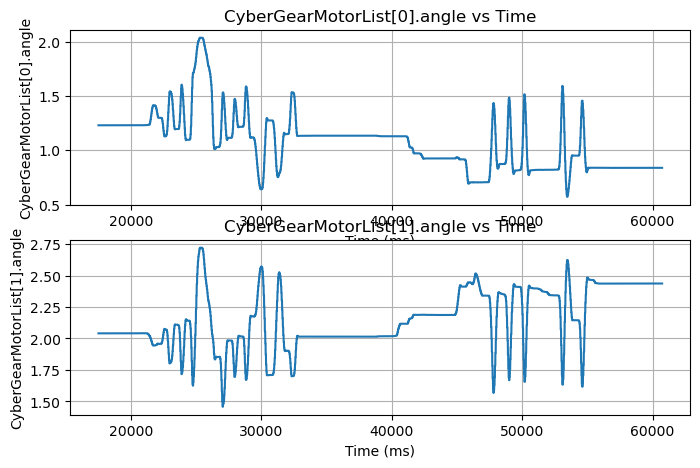

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_15_1['time(ms)'], filtered_df_15_1['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_15_1['time(ms)'], filtered_df_15_1['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 20 D = 1

In [21]:
start_spring_20_damp_1 = 13191
end_spring_20_damp_1 = 20999
# Plot the data inside this range
filtered_df_20_1 = df.iloc[start_spring_20_damp_1:end_spring_20_damp_1]

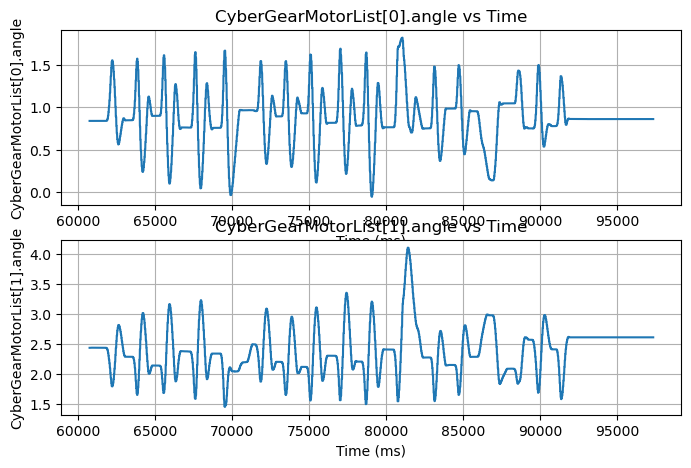

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_20_1['time(ms)'], filtered_df_20_1['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_20_1['time(ms)'], filtered_df_20_1['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 25 D = 1

In [26]:
start_spring_25_damp_1 = 20999
end_spring_25_damp_1 = 31142
# Plot the data inside this range
filtered_df_25_1 = df.iloc[start_spring_25_damp_1:end_spring_25_damp_1]

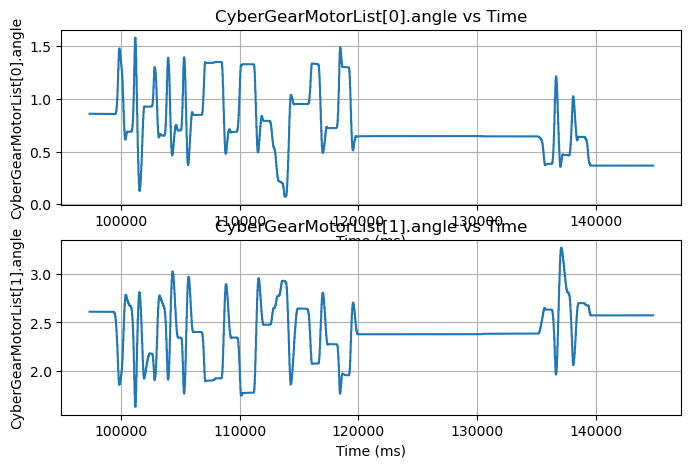

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_25_1['time(ms)'], filtered_df_25_1['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_25_1['time(ms)'], filtered_df_25_1['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 1

In [29]:
start_spring_30_damp_1 = 31143
end_spring_30_damp_1 = 41880
# Plot the data inside this range
filtered_df_30_1 = df.iloc[start_spring_30_damp_1:end_spring_30_damp_1]

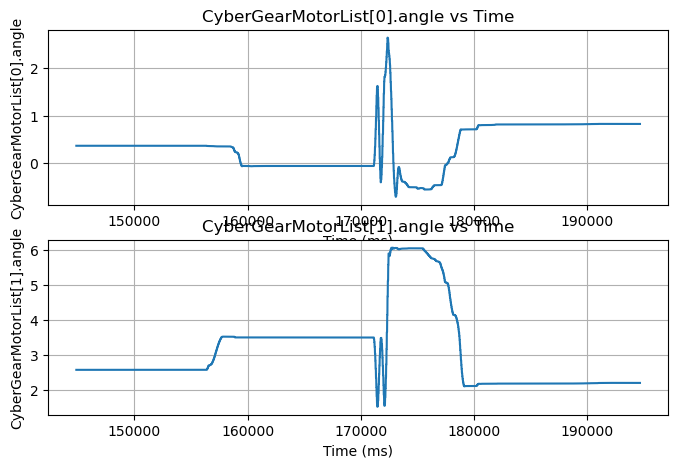

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_1['time(ms)'], filtered_df_30_1['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_1['time(ms)'], filtered_df_30_1['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 2

In [32]:
start_spring_30_damp_2 = 41880
end_spring_30_damp_2 = 47200
# Plot the data inside this range
filtered_df_30_2 = df.iloc[start_spring_30_damp_2:end_spring_30_damp_2]

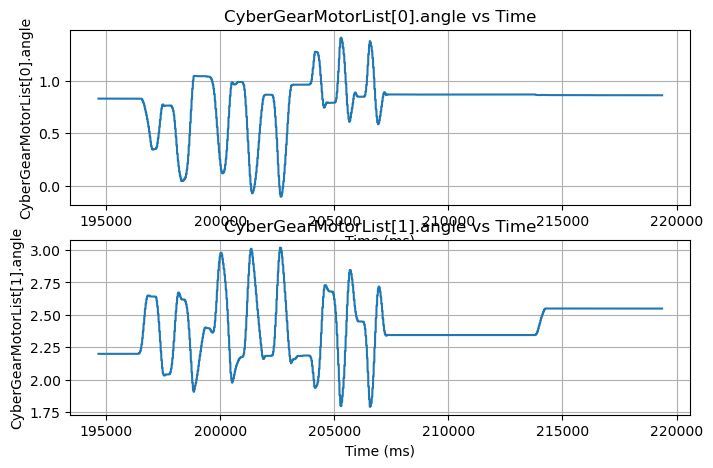

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_2['time(ms)'], filtered_df_30_2['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_2['time(ms)'], filtered_df_30_2['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 3

In [35]:
start_spring_30_damp_3 = 47201
end_spring_30_damp_3 = 49851
# Plot the data inside this range
filtered_df_30_3 = df.iloc[start_spring_30_damp_3:end_spring_30_damp_3]

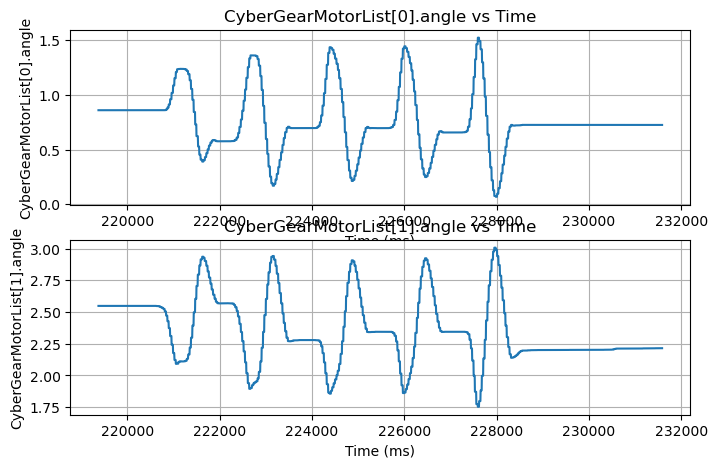

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_3['time(ms)'], filtered_df_30_3['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_3['time(ms)'], filtered_df_30_3['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 6

In [37]:
start_spring_30_damp_6 = 49851
end_spring_30_damp_6 = 52894
# Plot the data inside this range
filtered_df_30_6 = df.iloc[start_spring_30_damp_6:end_spring_30_damp_6]

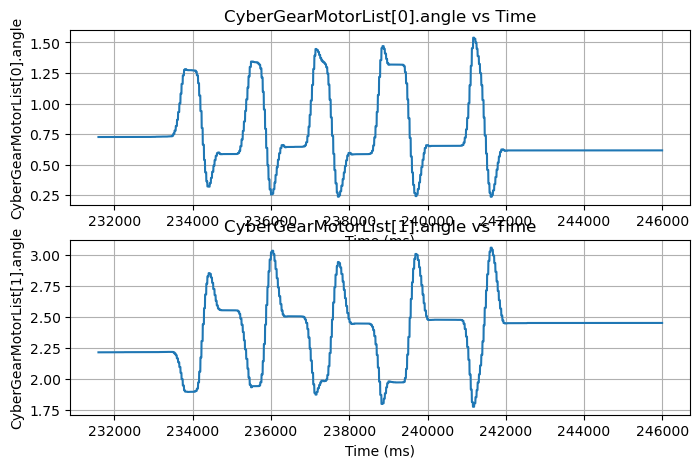

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_6['time(ms)'], filtered_df_30_6['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_6['time(ms)'], filtered_df_30_6['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 8

In [39]:
start_spring_30_damp_8 = 52894
end_spring_30_damp_8 = 55507
# Plot the data inside this range
filtered_df_30_8 = df.iloc[start_spring_30_damp_8:end_spring_30_damp_8]

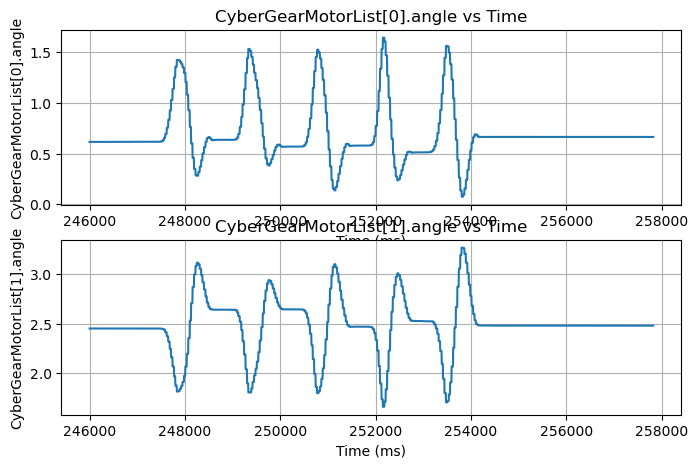

In [ ]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_8['time(ms)'], filtered_df_30_8['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_8['time(ms)'], filtered_df_30_8['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# PODATKI ZA K = 30 D = 10

In [42]:
start_spring_30_damp_10 = 55507
end_spring_30_damp_10 = 82016
# Plot the data inside this range
filtered_df_30_10 = df.iloc[start_spring_30_damp_10:end_spring_30_damp_10]

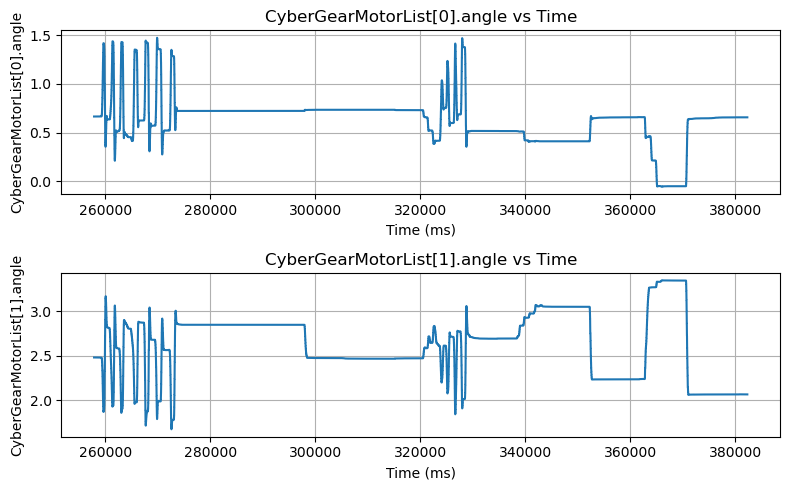

In [43]:
# make 2 subplots in 1 plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot 'CyberGearMotorList[0].angle' vs 'time(ms)'
ax[0].plot(filtered_df_30_10['time(ms)'], filtered_df_30_10['CyberGearMotorList[0].angle'])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('CyberGearMotorList[0].angle')
ax[0].set_title('CyberGearMotorList[0].angle vs Time')
ax[0].grid(True)

# Plot 'CyberGearMotorList[1].angle' vs 'time(ms)'
ax[1].plot(filtered_df_30_10['time(ms)'], filtered_df_30_10['CyberGearMotorList[1].angle'])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('CyberGearMotorList[1].angle')
ax[1].set_title('CyberGearMotorList[1].angle vs Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [14]:
import sympy as sp

# Define symbolic variables
phi1, phi2, l0, l1, l2 = sp.symbols('phi1 phi2 l0 l1 l2', real=True)

# Define Phi (capital Phi in the paper)
Phi = sp.sqrt(4*l2**2 / (l0**2 - 2*l1**2*sp.cos(phi1 - phi2)
                         + 2*l1**2 - 2*l0*l1*(sp.cos(phi1) - sp.cos(phi2))) - 1)

# Define x_c and y_c using the given formula
x_c = 0.5*(l0 + l1*(sp.cos(phi1) + sp.cos(phi2)) + l1*Phi*(sp.sin(phi1) - sp.sin(phi2)))
y_c = 0.5*(l1*(sp.sin(phi1) + sp.sin(phi2)) + l0*Phi
           - l1*Phi*(sp.cos(phi1) + sp.cos(phi2)))

# Take partial derivatives
dxc_dphi1 = sp.diff(x_c, phi1)
dxc_dphi2 = sp.diff(x_c, phi2)
dyc_dphi1 = sp.diff(y_c, phi1)
dyc_dphi2 = sp.diff(y_c, phi2)

# Print symbolic expressions
#sp.pprint(dxc_dphi1)
#sp.pprint(dxc_dphi2)
#sp.pprint(dyc_dphi1)
#sp.pprint(dyc_dphi2)


In [11]:
display(x_c)


0.5*l0 + 0.5*l1*sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1)*(sin(phi1) - sin(phi2)) + 0.5*l1*(cos(phi1) + cos(phi2))

In [12]:
display(y_c)


0.5*l0*sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1) - 0.5*l1*sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1)*(cos(phi1) + cos(phi2)) + 0.5*l1*(sin(phi1) + sin(phi2))

In [ ]:
display(Phi)


sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1)

In [23]:
sp.ccode(dxc_dphi1, assign_to='dxc_dphi1')

'dxc_dphi1 = 1.0*l1*pow(l2, 2)*(-2*l0*l1*sin(phi1) - 2*pow(l1, 2)*sin(phi1 - phi2))*(sin(phi1) - sin(phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) + 0.5*l1*sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*cos(phi1) - 0.5*l1*sin(phi1);'

In [19]:
sp.ccode(dxc_dphi2, assign_to='dxc_dphi2')

'dxc_dphi2 = 1.0*l1*pow(l2, 2)*(2*l0*l1*sin(phi2) + 2*pow(l1, 2)*sin(phi1 - phi2))*(sin(phi1) - sin(phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) - 0.5*l1*sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*cos(phi2) - 0.5*l1*sin(phi2);'

In [20]:
sp.ccode(dyc_dphi1, assign_to='dyc_dphi1')

'dyc_dphi1 = 1.0*l0*pow(l2, 2)*(-2*l0*l1*sin(phi1) - 2*pow(l1, 2)*sin(phi1 - phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) - 1.0*l1*pow(l2, 2)*(-2*l0*l1*sin(phi1) - 2*pow(l1, 2)*sin(phi1 - phi2))*(cos(phi1) + cos(phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) + 0.5*l1*sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*sin(phi1) + 0.5*l1*cos(phi1);'

In [21]:
sp.ccode(dyc_dphi2, assign_to='dyc_dphi2')

'dyc_dphi2 = 1.0*l0*pow(l2, 2)*(2*l0*l1*sin(phi2) + 2*pow(l1, 2)*sin(phi1 - phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) - 1.0*l1*pow(l2, 2)*(2*l0*l1*sin(phi2) + 2*pow(l1, 2)*sin(phi1 - phi2))*(cos(phi1) + cos(phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) + 0.5*l1*sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*sin(phi2) + 0.5*l1*cos(phi2);'

In [26]:
simplified_dxc_dphi1 = sp.simplify(dxc_dphi1)

In [34]:
simplified_dxc_dphi2 = sp.simplify(dxc_dphi2)

In [35]:
simplified_dyc_dphi1 = sp.simplify(dyc_dphi1)

In [ ]:
simplified_dyc_dphi2 = sp.simplify(dyc_dphi2)

In [27]:
display(simplified_dxc_dphi1)

-1.0*l1*l2**2*(2*l0*l1*sin(phi1) + 2*l1**2*sin(phi1 - phi2))*(sin(phi1) - sin(phi2))/(sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1)*(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2)**2) + 0.5*l1*sqrt(4*l2**2/(l0**2 - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*l1**2*cos(phi1 - phi2) + 2*l1**2) - 1)*cos(phi1) - 0.5*l1*sin(phi1)

In [28]:
sp.ccode(simplified_dxc_dphi1, assign_to='dxc_dphi1_simplified')

'dxc_dphi1_simplified = -1.0*l1*pow(l2, 2)*(2*l0*l1*sin(phi1) + 2*pow(l1, 2)*sin(phi1 - phi2))*(sin(phi1) - sin(phi2))/(sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*pow(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2), 2)) + 0.5*l1*sqrt(4*pow(l2, 2)/(pow(l0, 2) - 2*l0*l1*(cos(phi1) - cos(phi2)) - 2*pow(l1, 2)*cos(phi1 - phi2) + 2*pow(l1, 2)) - 1)*cos(phi1) - 0.5*l1*sin(phi1);'

In [33]:
replacements, reduced_expr = sp.cse(simplified_dxc_dphi1)
# Print out the common subexpressions
print("Common Subexpressions:")
for var, sub_expr in replacements:
    print(f"{var} = {sp.pretty(sub_expr)}")

# Print the final reduced expression
print("\nReduced Expression:")
sp.pprint(reduced_expr[0])

# Optionally, generate C code using the replacements and the reduced expression:
c_code = ""
for var, sub_expr in replacements:
    c_code += sp.ccode(var, assign_to=str(var)) + " = " + sp.ccode(sub_expr) + ";\n"
c_code += "result = " + sp.ccode(reduced_expr[0]) + ";\n"

print("\nGenerated C Code:")
print(c_code)

Common Subexpressions:
x0 = sin(φ₁)
x1 = cos(φ₁)
x2 =   2
l₂ 
x3 =     2
2⋅l₁ 
x4 = φ₁ - φ₂
x5 = 2⋅l₀⋅l₁
x6 =   2                                      
l₀  - x₃⋅cos(x₄) + x₃ - x₅⋅(x₁ - cos(φ₂))
x7 =     __________
   ╱ 4⋅x₂     
  ╱  ──── - 1 
╲╱    x₆      

Reduced Expression:
                            1.0⋅l₁⋅x₂⋅(x₀ - sin(φ₂))⋅(x₀⋅x₅ + x₃⋅sin(x₄))
-0.5⋅l₁⋅x₀ + 0.5⋅l₁⋅x₁⋅x₇ - ─────────────────────────────────────────────
                                                 2                       
                                               x₆ ⋅x₇                    

Generated C Code:
x0 = x0; = sin(phi1);
x1 = x1; = cos(phi1);
x2 = x2; = pow(l2, 2);
x3 = x3; = 2*pow(l1, 2);
x4 = x4; = phi1 - phi2;
x5 = x5; = 2*l0*l1;
x6 = x6; = pow(l0, 2) - x3*cos(x4) + x3 - x5*(x1 - cos(phi2));
x7 = x7; = sqrt(4*x2/x6 - 1);
result = -0.5*l1*x0 + 0.5*l1*x1*x7 - 1.0*l1*x2*(x0 - sin(phi2))*(x0*x5 + x3*sin(x4))/(pow(x6, 2)*x7);



In [ ]:
replacements, reduced_expr = sp.cse(simplified_dxc_dphi2)
# Print out the common subexpressions
print("Common Subexpressions:")
for var, sub_expr in replacements:
    print(f"{var} = {sp.pretty(sub_expr)}")

# Print the final reduced expression
print("\nReduced Expression:")
sp.pprint(reduced_expr[0])

# Optionally, generate C code using the replacements and the reduced expression:
c_code = ""
for var, sub_expr in replacements:
    c_code += sp.ccode(var, assign_to=str(var)) + " = " + sp.ccode(sub_expr) + ";\n"
c_code += "result = " + sp.ccode(reduced_expr[0]) + ";\n"

print("\nGenerated C Code:")
print(c_code)